# Stage 2: predict the attack type

This is the second stage of the IDS. It reads attack records only and names
the attack. `BENIGN` is removed, because benign traffic has no attack type.

The target is the `attack_category` column. That column groups the three web
attacks (Brute Force, XSS, SQL Injection) into one `Web Attack` class, as
Table 3 of the CIC-IDS2017 paper does. The categories are:

`Bot`, `DDoS`, `DoS GoldenEye`, `DoS Hulk`, `DoS Slowhttptest`,
`DoS slowloris`, `FTP-Patator`, `Heartbleed`, `Infiltration`, `PortScan`,
`SSH-Patator`, `Web Attack`.

Set `TARGET_COLUMN` to `attack_label` to separate the three web attacks
again.

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score,
)

RANDOM_STATE = 42
TARGET_COLUMN = "attack_category"
RUN_TRAINING = True

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_FILE = PROJECT_ROOT / "dataset/processed/train.parquet"
TEST_FILE = PROJECT_ROOT / "dataset/processed/test.parquet"
FEATURE_FILE = PROJECT_ROOT / "artifacts/feature_selection/selected_features.json"
OUTPUT_FOLDER = PROJECT_ROOT / "artifacts/attack_type_model"

## 1. Load the attack rows

The stage reuses the twenty features of stage 1.

In [2]:
feature_report = json.loads(FEATURE_FILE.read_text(encoding="utf-8"))
features = feature_report["selected_features"]
columns = features + [TARGET_COLUMN]

train = pd.read_parquet(TRAIN_FILE, columns=columns)
test = pd.read_parquet(TEST_FILE, columns=columns)
train = train[train[TARGET_COLUMN] != "BENIGN"]
test = test[test[TARGET_COLUMN] != "BENIGN"]

x_train, y_train = train[features], train[TARGET_COLUMN].astype(str)
x_test, y_test = test[features], test[TARGET_COLUMN].astype(str)

print(f"Training attacks: {len(train):,}")
print(f"Testing attacks:  {len(test):,}")

class_counts = pd.DataFrame({
    "train": y_train.value_counts(),
    "test": y_test.value_counts(),
}).fillna(0).astype(int).sort_values("train", ascending=False)
class_counts["train share %"] = (class_counts["train"] / len(y_train) * 100).round(3)
display(class_counts)

# The split of notebook 00 is stratified by attack label, so every class must
# be present in both partitions.
missing = set(y_test) - set(y_train)
assert not missing, f"Classes only in the test data: {missing}"
print("Every test class is also in the training data.")

Training attacks: 340,581
Testing attacks:  85,145


,train,test,train share %
attack_category,,,
DoS Hulk,138277,34569,40.600
DDoS,102411,25603,30.069
PortScan,72555,18139,21.303
DoS GoldenEye,8226,2056,2.415
FTP-Patator,4745,1186,1.393
DoS slowloris,4299,1075,1.262
DoS Slowhttptest,4182,1046,1.228
SSH-Patator,2575,644,0.756
Web Attack,1715,428,0.504


Every test class is also in the training data.


## 2. Train Random Forest

Balanced class weights reduce the effect of the large difference between the
common classes (DoS Hulk, DDoS, PortScan) and the rare classes (Heartbleed,
Infiltration).

In [3]:
if RUN_TRAINING:
    model = RandomForestClassifier(
        n_estimators=150,
        max_depth=25,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    start = time.perf_counter()
    model.fit(x_train, y_train)
    training_seconds = time.perf_counter() - start
    print(f"Training completed in {training_seconds:.1f} seconds")

Training completed in 29.0 seconds


## 3. Evaluate every attack class

Macro scores give every attack type equal importance, including the rare
classes. The weighted score follows the large classes, so it always looks
high. Both are reported.

In [4]:
if RUN_TRAINING:
    start = time.perf_counter()
    predictions = model.predict(x_test)
    prediction_seconds = time.perf_counter() - start

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision_macro": precision_score(y_test, predictions, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, predictions, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, predictions, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, predictions, average="weighted", zero_division=0),
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
    }

    # The label list covers the classes of the model and of the test data, so
    # a class that the model never predicts still appears in the report.
    labels = sorted(set(model.classes_) | set(pd.unique(y_test)))
    per_class = classification_report(
        y_test, predictions, labels=labels, output_dict=True, zero_division=0
    )
    display(pd.Series(metrics).to_frame("value").round(4))
    display(pd.DataFrame(per_class).transpose().round(4))

,value
accuracy,0.9994
precision_macro,0.9971
recall_macro,0.9852
f1_macro,0.9907
f1_weighted,0.9994
training_seconds,29.0064
prediction_seconds,0.5541


,precision,recall,f1-score,support
Bot,0.9974,1.0000,0.9987,390.0000
DDoS,1.0000,0.9999,0.9999,25603.0000
DoS GoldenEye,0.9961,0.9971,0.9966,2056.0000
DoS Hulk,0.9995,0.9999,0.9997,34569.0000
DoS Slowhttptest,0.9943,0.9924,0.9933,1046.0000
DoS slowloris,0.9925,0.9907,0.9916,1075.0000
FTP-Patator,1.0000,1.0000,1.0000,1186.0000
Heartbleed,1.0000,1.0000,1.0000,2.0000
Infiltration,1.0000,0.8571,0.9231,7.0000
PortScan,0.9998,0.9994,0.9996,18139.0000


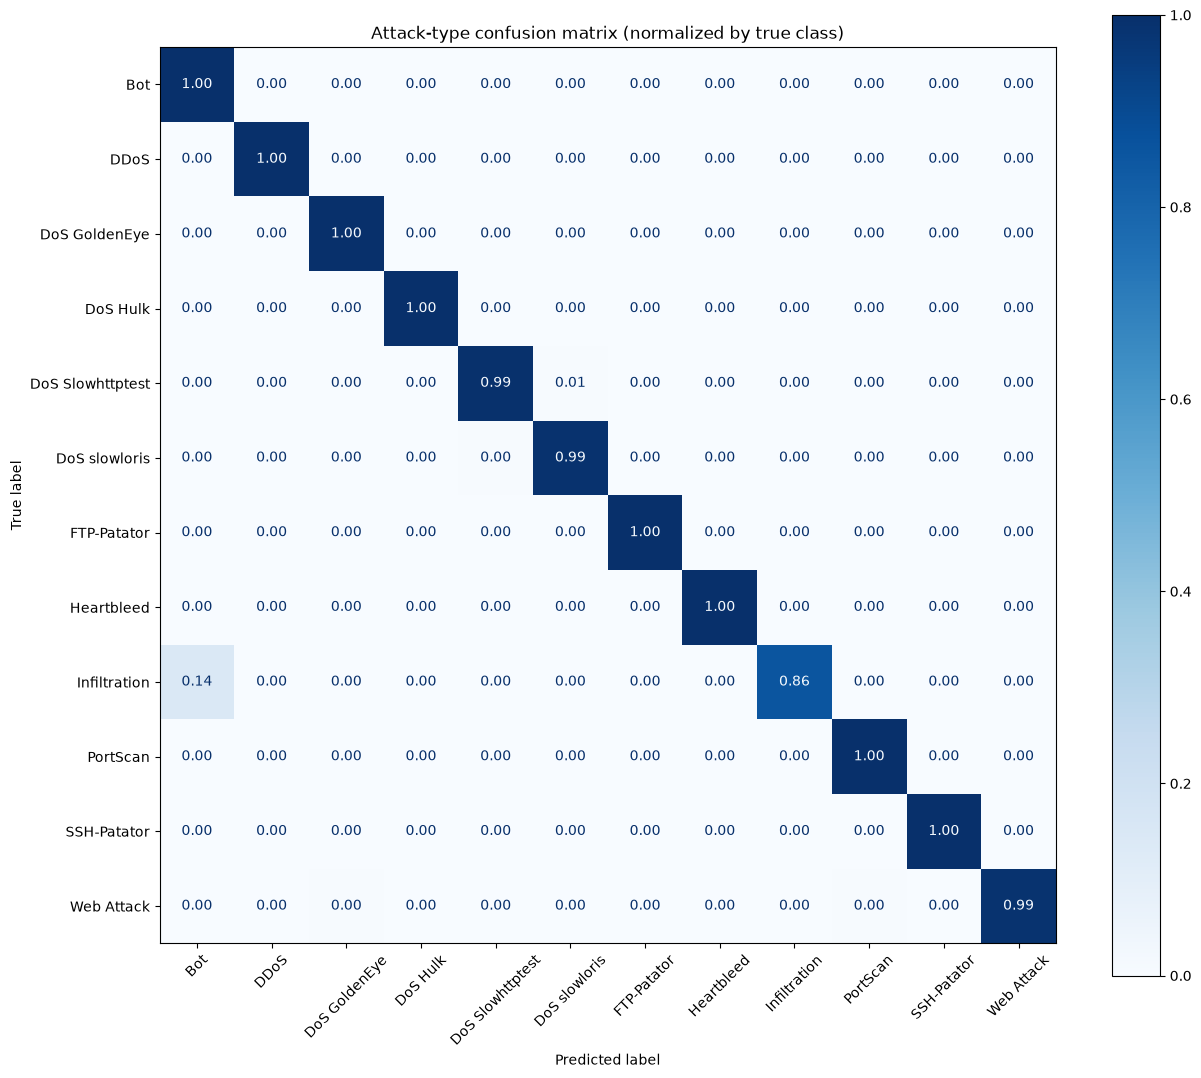

In [5]:
if RUN_TRAINING:
    figure, axis = plt.subplots(figsize=(13, 11))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions, labels=labels, display_labels=labels,
        normalize="true", values_format=".2f", cmap="Blues",
        xticks_rotation=45, ax=axis,
    )
    axis.set_title("Attack-type confusion matrix (normalized by true class)")
    plt.tight_layout()
    plt.show()

## 4. Save the trained model and the results

In [6]:
if RUN_TRAINING:
    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, OUTPUT_FOLDER / "random_forest_attack_type.joblib")
    figure.savefig(OUTPUT_FOLDER / "confusion_matrix.png", dpi=150)
    pd.DataFrame(per_class).transpose().to_csv(OUTPUT_FOLDER / "per_class_metrics.csv")

    report = {
        "model": "Random Forest",
        "task": "multiclass attack-type classification",
        "target_column": TARGET_COLUMN,
        "random_state": RANDOM_STATE,
        "classes": model.classes_.tolist(),
        "selected_features": features,
        "training_rows": len(x_train),
        "testing_rows": len(x_test),
        "training_class_counts": y_train.value_counts().sort_index().to_dict(),
        "testing_class_counts": y_test.value_counts().sort_index().to_dict(),
        "metrics": metrics,
        "per_class_metrics": per_class,
    }
    (OUTPUT_FOLDER / "report.json").write_text(
        json.dumps(report, indent=2), encoding="utf-8"
    )
    print(f"Saved results in {OUTPUT_FOLDER}")

Saved results in D:\Learn\Master\SBU\Network Security\Final Project\CICIDS2017-ML-IDS\artifacts\attack_type_model


## Notes

- This stage measures only the attack rows. Notebook 05 measures the two stages together.
- Heartbleed and Infiltration have very few records. Their scores move a lot when one record changes, so they are not a stable measurement.
- The model reuses the features that were selected for the binary task. Features chosen for each attack type could give a higher macro F1-score.